In [1]:
!pip install lifelines -q

In [2]:
# ==========================================================
# COLAB ENTERPRISE + BIGQUERY TABLE + DUCKDB + PYARROW (RAM)
# Hybrid SQL + Python
# Source:
# marketing-channel-roi.native_raw_channel_dataset.aggregate_raw_data
# ==========================================================

# Install if needed
# !pip install duckdb pyarrow google-cloud-bigquery bigquery-storage pandas -q

import duckdb
import pandas as pd
import pyarrow as pa
from google.cloud import bigquery
from google.cloud import bigquery_storage

# ----------------------------------------------------------
# 1. BigQuery Clients
# ----------------------------------------------------------
bq_client = bigquery.Client(project="marketing-channel-roi")
bqstorage_client = bigquery_storage.BigQueryReadClient()

# ----------------------------------------------------------
# 2. Read BigQuery table into PyArrow (RAM)
# ----------------------------------------------------------
table_id = "marketing-channel-roi.native_raw_channel_dataset.aggregate_raw_data"

query = f"""
SELECT *
FROM `{table_id}`
"""

df_arrow = bq_client.query(query).to_arrow(
    bqstorage_client=bqstorage_client
)

print("Rows:", df_arrow.num_rows)
print("Columns:", df_arrow.num_columns)

# ----------------------------------------------------------
# 3. Load PyArrow into DuckDB RAM
# ----------------------------------------------------------
con = duckdb.connect()

con.register("raw_tbl", df_arrow)

# ----------------------------------------------------------
# 4. SQL Query in DuckDB
# ----------------------------------------------------------
preview = con.sql("""
SELECT *
FROM raw_tbl
LIMIT 10
""").df()

display(preview)


Rows: 2417598
Columns: 21


,msno,total_transactions,sum_payment_plan_days,sum_plan_list_price,sum_actual_amount_paid,avg_payment_plan_days,avg_plan_list_price,avg_actual_amount_paid,first_transaction_date,last_transaction_date,...,total_discount_burn,latest_payment_method_id,latest_is_auto_renew,latest_is_cancel,registered_via,registration_init_time,Tenure_Days,is_Churned,is_discounted,is_High_Value_User
0,o7pXndY8SJQJzO3hwift2dcas8aR4HsVPom5kULsK1o=,2,0,0.0,9.61,0.0,0.0,4.81,2015-03-31,2015-05-06,...,0.0,33,1,1,9,2009-09-16,35,1,0,0
1,3Fp16h9GJhBlwrNDN95mQ271Q3w/PEn4koEWLI/YxrU=,2,0,0.0,0.00,0.0,0.0,0.00,2015-05-03,2015-05-03,...,0.0,41,1,0,Missing Info,1900-01-01,30,1,0,0
2,kUj38eCeWYlrFZjnRF4BWO4T7wanIAKyEride7S/KIU=,2,0,0.0,0.00,0.0,0.0,0.00,2015-05-02,2015-05-03,...,0.0,41,1,1,Missing Info,1900-01-01,31,1,0,0
3,pAX+r1O1lFQMm5HeCl9kdrL/P3/hp0f+VpPVDX57Kd8=,2,0,0.0,9.61,0.0,0.0,4.81,2015-03-31,2015-05-03,...,0.0,33,1,1,9,2007-05-01,30,1,0,0
4,dyNl5TZGrvD1FDaisGrVgHtOl1q+0F/GKuf8DOEs+XU=,2,0,0.0,9.61,0.0,0.0,4.81,2015-03-31,2015-05-07,...,0.0,33,1,1,9,2006-05-30,36,1,0,0
5,KwtzDl+6FeyV/gtmtN7ocEBu9LbqUr2Dhe3vUUYusUU=,1,0,0.0,4.84,0.0,0.0,4.84,2015-05-11,2015-05-11,...,0.0,36,0,0,9,2015-05-03,30,1,0,0
6,8xBxJPPmJ5Vqy9CsvI5F0HiRzdkm9XAIs7wHRn5s5aY=,1,0,0.0,4.81,0.0,0.0,4.81,2015-04-26,2015-04-26,...,0.0,38,0,0,9,2012-04-23,30,1,0,0
7,flZagA2zmt4D3MpzcknAGFCmK3fkjpoQ74f+jZUpFUk=,1,0,0.0,4.84,0.0,0.0,4.84,2015-05-12,2015-05-12,...,0.0,36,0,0,9,2011-08-28,30,1,0,0
8,ZttOIduNurnf53w7ftAPuTV+K/h3lCPyTAXHDmmiwZM=,1,0,0.0,28.84,0.0,0.0,28.84,2015-05-04,2015-05-04,...,0.0,38,0,0,9,2013-05-04,195,1,0,0
9,cfqrrdH2Ej+hOEUuUMYEXC9pZ6LQ5NwEyatkakEU83M=,1,0,0.0,4.81,0.0,0.0,4.81,2015-04-25,2015-04-25,...,0.0,38,0,0,9,2015-04-25,31,1,0,0


--- 📊 TOTAL CHANNELS FOUND: 8 ---


,registered_via,User_Count,Percentage (%)
5,7,678287,27.96
6,9,634577,26.16
7,Missing Info,437810,18.05
3,3,401095,16.53
4,4,269454,11.11
1,13,4910,0.20
0,10,9,0.00
2,16,1,0.00


/tmp/ipykernel_778/1183450767.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=channel_dist, x='registered_via', y='User_Count', palette='viridis')


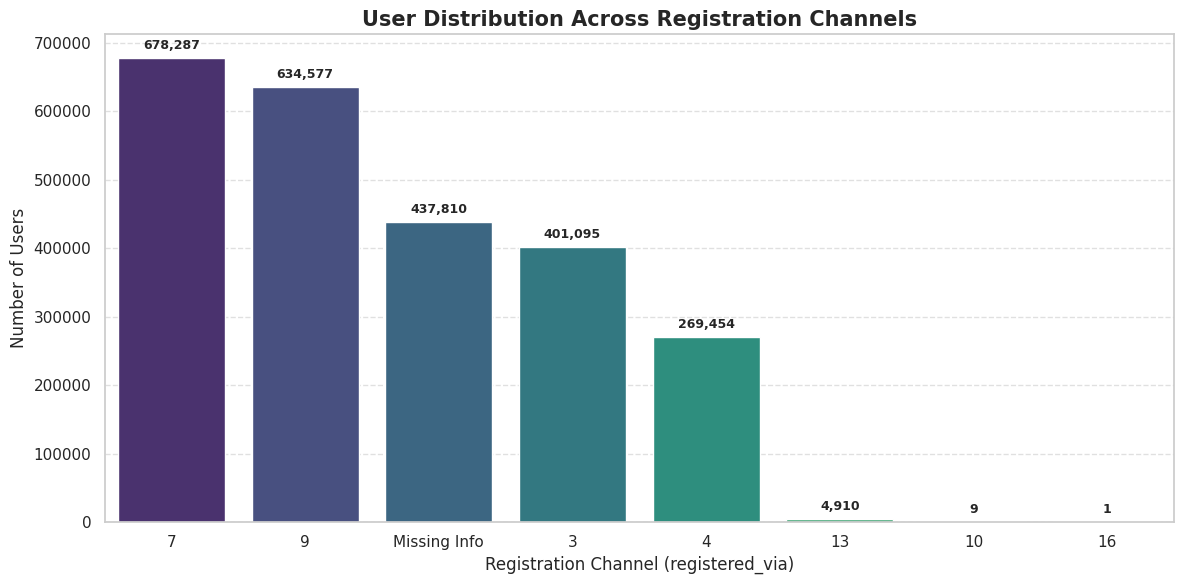

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

# 1. LOAD DATA (Sirf zaroori columns)
target_path = "marketing-channel-roi.native_raw_channel_dataset.aggregate_raw_data"

client = bigquery.Client()

query = f"""
SELECT msno, registered_via
FROM `{target_path}`
"""

df_channels = client.query(query).to_dataframe()

# 2. CALCULATE DISTRIBUTION
channel_dist = df_channels.groupby('registered_via').agg(
    User_Count=('msno', 'count')
).reset_index()

# Sort by count
channel_dist = channel_dist.sort_values(by='User_Count', ascending=False)

# Percentage calculation
total_users = channel_dist['User_Count'].sum()
channel_dist['Percentage (%)'] = ((channel_dist['User_Count'] / total_users) * 100).round(2)

# 3. DISPLAY TABLE
print(f"--- 📊 TOTAL CHANNELS FOUND: {len(channel_dist)} ---")
display(channel_dist)

# 4. VISUALIZE
plt.figure(figsize=(12,6))
ax = sns.barplot(data=channel_dist, x='registered_via', y='User_Count', palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center',
                xytext=(0,9),
                textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.title('User Distribution Across Registration Channels', fontsize=15, fontweight='bold')
plt.xlabel('Registration Channel (registered_via)', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

,Revenue Tier (Customer Type),Exact User Count,% of Total Base
0,1. The Freeloaders ($0),620152,25.56
3,2. Low Tier ($1 - $16),339354,13.99
4,3. Below Average ($17 - $33),253261,10.44
1,4. Standard Tier ($34 - $80),606230,24.99
2,5. The VIP Club ($81 - $160),595469,24.54
5,6. The Whales ($160+),11677,0.48


/tmp/ipykernel_778/2348023497.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


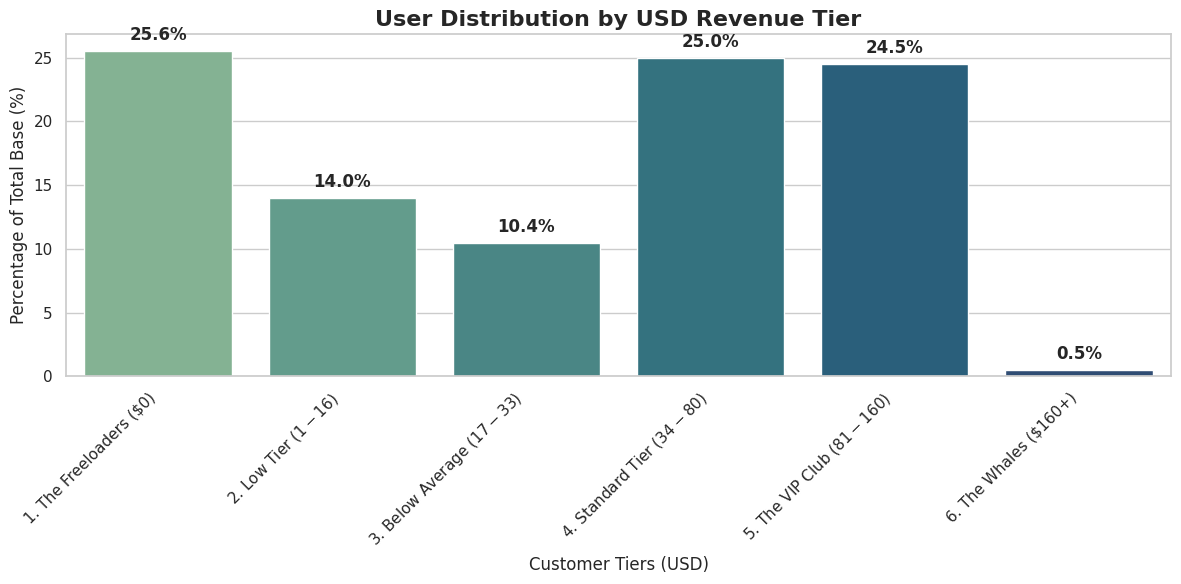

In [ ]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==================================================
# LOAD DATA FROM YOUR BASE TABLE: raw_tbl
# (Assuming your dbt model has already converted this to USD)
# ==================================================
df = con.sql("""
SELECT sum_actual_amount_paid
FROM raw_tbl
""").df()

# ==================================================
# BUCKETS (UPDATED TO USD $)
# Original NTD: 0, 500, 1032, 2489, 5000
# New USD: 0, 16, 33, 80, 160
# ==================================================
bins = [-1, 0, 16, 33, 80, 160, float('inf')]

labels = [
    '1. The Freeloaders ($0)',
    '2. Low Tier ($1 - $16)',
    '3. Below Average ($17 - $33)',
    '4. Standard Tier ($34 - $80)',
    '5. The VIP Club ($81 - $160)',
    '6. The Whales ($160+)'
]

# ==================================================
# SEGMENTATION
# ==================================================
df['revenue_tier'] = pd.cut(
    df['sum_actual_amount_paid'],
    bins=bins,
    labels=labels
)

# ==================================================
# DISTRIBUTION TABLE
# ==================================================
distribution_table = df['revenue_tier'].value_counts().reset_index()
distribution_table.columns = [
    'Revenue Tier (Customer Type)',
    'Exact User Count'
]

distribution_table['% of Total Base'] = (
    distribution_table['Exact User Count'] / len(df) * 100
).round(2)

distribution_table['Revenue Tier (Customer Type)'] = pd.Categorical(
    distribution_table['Revenue Tier (Customer Type)'],
    categories=labels,
    ordered=True
)

distribution_table = distribution_table.sort_values(
    by='Revenue Tier (Customer Type)'
)

display(distribution_table)

# ==================================================
# CHART
# ==================================================
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Using a sleek color palette for financial data
ax = sns.barplot(
    data=distribution_table,
    x='Revenue Tier (Customer Type)',
    y='% of Total Base',
    palette='crest'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontweight='bold',
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.title('User Distribution by USD Revenue Tier', fontsize=16, fontweight='bold')
plt.xlabel('Customer Tiers (USD)')
plt.ylabel('Percentage of Total Base (%)')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# SCRIPT 2: THE CFO REPORTING ENGINE
# Goal: Analyze Which Channel Pays the Bills
# Base Source = raw_tbl (DuckDB RAM)
# ==========================================

import pandas as pd
from IPython.display import display, HTML

print("📊 Generating Channel ROI Report (USD Normalized)...\n")

# 1. LOAD ONLY REQUIRED COLUMNS (WITH CLEAN DATA FILTER)
df_report = con.sql("""
    SELECT
        msno,
        registered_via,
        is_High_Value_User,
        sum_actual_amount_paid
    FROM raw_tbl
    WHERE Tenure_Days >= 0 -- 🛡️ The Senior Filter: Dropping corrupt rows
""").df()

# 2. THE CHANNEL MASTER TABLE
channel_roi = df_report.groupby('registered_via', observed=False).agg(
    Total_Users=('msno', 'count'),
    Total_VIPs=('is_High_Value_User', 'sum'),
    Total_Revenue_USD=('sum_actual_amount_paid', 'sum')
).reset_index()

# 3. NOISE REDUCTION (Ignore tiny test channels)
channel_roi = channel_roi[channel_roi['Total_Users'] > 1000].copy()

# 4. CALCULATING THE METRICS
channel_roi['VIP_Conversion_Rate (%)'] = (
    channel_roi['Total_VIPs'] / channel_roi['Total_Users'] * 100
)

channel_roi['Avg_Revenue_Per_User (USD)'] = (
    channel_roi['Total_Revenue_USD'] / channel_roi['Total_Users']
)

# 5. SORTING
channel_roi = channel_roi.sort_values(
    by='Total_Revenue_USD',
    ascending=False
)

# 6. DISPLAY RESULTS (WITH CFO-LEVEL STYLING)
print("--- 🏆 WHICH CHANNEL IS PAYING OUR BILLS? ---")

# Apply styling to make it look like a real financial document
styled_roi = channel_roi.head(10).style.format({
    "Total_Users": "{:,.0f}",
    "Total_VIPs": "{:,.0f}",
    "Total_Revenue_USD": "${:,.2f}",
    "VIP_Conversion_Rate (%)": "{:.2f}%",
    "Avg_Revenue_Per_User (USD)": "${:,.2f}"
}).hide(axis="index")

display(HTML(styled_roi.to_html()))

📊 Generating Channel ROI Report (USD Normalized)...

--- 🏆 WHICH CHANNEL IS PAYING OUR BILLS? ---


registered_via,Total_Users,Total_VIPs,Total_Revenue_USD,VIP_Conversion_Rate (%),Avg_Revenue_Per_User (USD)
7,"675,249","167,731","$40,599,185.04",24.84%,$60.12
9,"633,909","262,583","$40,330,324.80",41.42%,$63.62
3,"400,756","98,150","$17,252,086.33",24.49%,$43.05
Missing Info,"433,347","23,213","$9,218,191.00",5.36%,$21.27
4,"269,417","6,292","$4,197,522.08",2.34%,$15.58
13,"4,910",1,"$68,895.60",0.02%,$14.03


# What is the expected 'Active Life' of a user from each channel?

Data prepped for Survival Analysis. Rows: 2421223


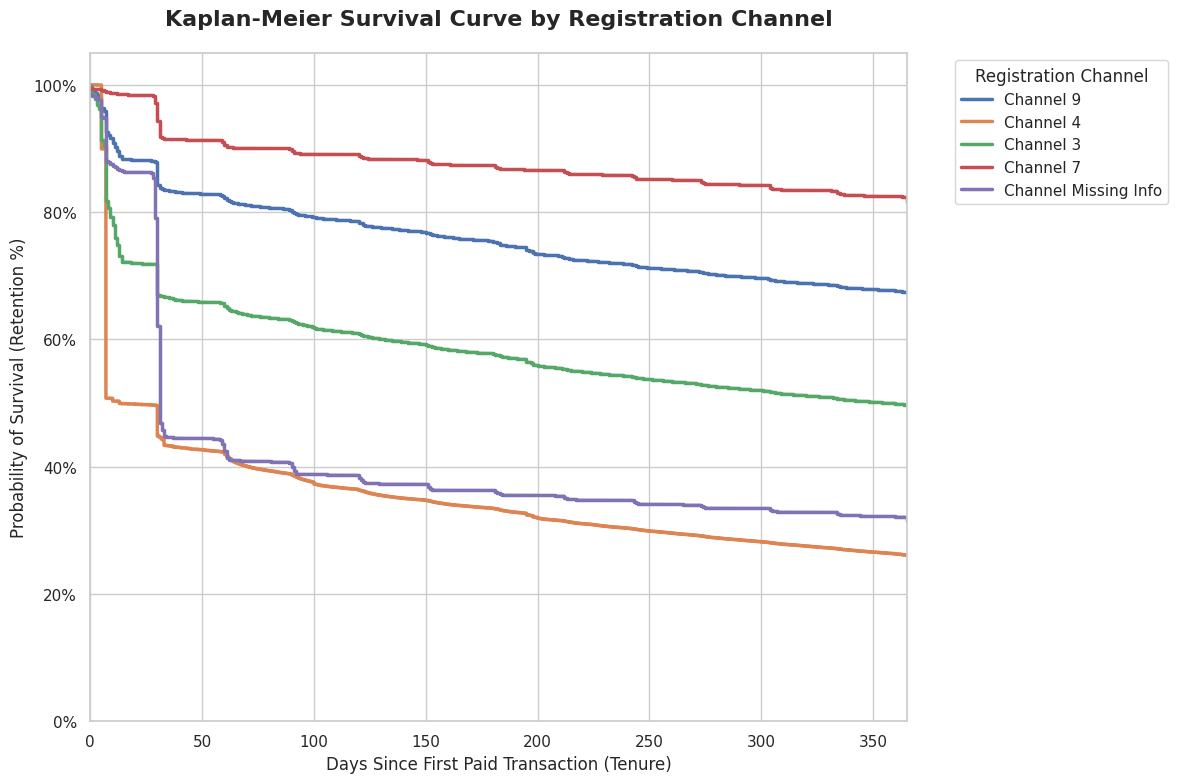

In [ ]:
# ==========================================================
# 5. KAPLAN-MEIER SURVIVAL ANALYSIS (EDA)
# ==========================================================

# Run this once in Colab to install the survival library
# !pip install lifelines matplotlib seaborn -q

import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter

# Set a professional visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# --- A. Extract Data via DuckDB ---
# We use DuckDB to filter for only the Top 5 channels by volume
# so the graph remains readable for the portfolio.
km_df = con.sql("""
WITH Top_Channels AS (
    SELECT registered_via, COUNT(*) as user_count
    FROM raw_tbl
    GROUP BY registered_via
    ORDER BY user_count DESC
    LIMIT 5
)
SELECT
    t.registered_via,
    t.Tenure_Days,
    t.is_Churned
FROM raw_tbl t
JOIN Top_Channels c ON t.registered_via = c.registered_via
WHERE t.Tenure_Days IS NOT NULL
  AND t.is_Churned IS NOT NULL
""").df()

print(f"Data prepped for Survival Analysis. Rows: {len(km_df)}")

# --- B. Build the Survival Curve ---
# Initialize the Kaplan-Meier Fitter
kmf = KaplanMeierFitter()

# Create the plot
fig, ax = plt.subplots()

# Loop through each of the Top 5 channels and plot its curve
unique_channels = km_df['registered_via'].unique()

for channel in unique_channels:
    # Filter dataframe for the specific channel
    mask = km_df['registered_via'] == channel

    # Fit the data: kmf.fit(durations, event_observed, label)
    kmf.fit(
        durations=km_df.loc[mask, 'Tenure_Days'],
        event_observed=km_df.loc[mask, 'is_Churned'],
        label=f'Channel {channel}'
    )

    # Plot the curve
    kmf.plot_survival_function(ax=ax, linewidth=2.5)

# --- C. Format the Dashboard Visual ---
plt.title('Kaplan-Meier Survival Curve by Registration Channel', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Days Since First Paid Transaction (Tenure)', fontsize=12)
plt.ylabel('Probability of Survival (Retention %)', fontsize=12)

# Set axes limits for clarity (e.g., viewing the first 365 days)
plt.xlim(0, 365)
plt.ylim(0, 1.05)

# Format Y-axis as percentages
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend(title='Registration Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Render the graph in Colab
plt.show()

In [ ]:
# ==========================================================
# 6. EXECUTIVE RETENTION TABLE (The "Full Story")
# ==========================================================
import pandas as pd
from IPython.display import display, HTML

# These are the milestones the CFO and Marketing teams actually care about
milestone_days = [1, 7, 30, 90, 180, 365]
table_rows = []

# Assuming unique_channels and km_df are still in memory from the previous block
for channel in unique_channels:
    mask = km_df['registered_via'] == channel

    # Re-fit the model for each channel
    kmf_table = KaplanMeierFitter()
    kmf_table.fit(
        durations=km_df.loc[mask, 'Tenure_Days'],
        event_observed=km_df.loc[mask, 'is_Churned']
    )

    # Extract the exact survival probabilities at our milestone days
    # (survival_function_at_times handles the interpolation perfectly)
    survival_probs = kmf_table.survival_function_at_times(milestone_days).values

    # Create a dictionary for this channel's row
    row_data = {'Registration Channel': f"Channel {channel}"}

    for day, prob in zip(milestone_days, survival_probs):
        # Format as a clean percentage (e.g., 85.4%)
        row_data[f'Day {day} Retention'] = f"{prob * 100:.1f}%"

    table_rows.append(row_data)

# Create the final Pandas DataFrame
retention_df = pd.DataFrame(table_rows)

# Sort it by Day 365 Retention to show the highest value channels at the top
# (We sort the string values by stripping the '%' and converting to float)
retention_df = retention_df.sort_values(
    by='Day 365 Retention',
    key=lambda x: x.str.rstrip('%').astype(float),
    ascending=False
).reset_index(drop=True)

# Display as a clean HTML table in Colab
print("\n--- EXECUTIVE RETENTION MILESTONES ---")
display(HTML(retention_df.to_html(classes='table table-striped', index=False)))


--- EXECUTIVE RETENTION MILESTONES ---


Registration Channel,Day 1 Retention,Day 7 Retention,Day 30 Retention,Day 90 Retention,Day 180 Retention,Day 365 Retention
Channel 7,99.4%,98.8%,94.3%,89.6%,87.3%,81.5%
Channel 9,99.1%,92.6%,84.2%,80.0%,75.3%,67.3%
Channel 3,98.5%,81.7%,67.0%,62.8%,57.6%,49.6%
Channel Missing Info,98.2%,88.0%,62.1%,40.0%,36.3%,31.4%
Channel 4,100.0%,50.7%,44.8%,38.7%,33.4%,26.1%


In [ ]:
# ==========================================================
# 7. AVERAGE ACTIVE LIFE (MEAN TENURE) BY CHANNEL
# ==========================================================
from IPython.display import display, HTML

# We use DuckDB to aggregate the data efficiently.
# We also convert days to months (Days / 30.4) because CEOs think in months/years, not thousands of days.
avg_tenure_df = con.sql("""
    SELECT
        registered_via AS "Registration Channel",
        COUNT(*) AS "Total Users",
        ROUND(AVG(Tenure_Days), 1) AS "Avg Active Life (Days)",
        ROUND(AVG(Tenure_Days) / 30.4, 1) AS "Avg Active Life (Months)"
    FROM raw_tbl
    WHERE Tenure_Days >= 0  -- Filters out any weird negative data anomalies
    GROUP BY registered_via
    HAVING COUNT(*) > 1000  -- Removes tiny test channels with no statistical significance
    ORDER BY "Avg Active Life (Days)" DESC
""").df()

# Display as a clean HTML table
print("\n--- AVERAGE ACTIVE LIFE (MEAN TENURE) BY CHANNEL ---")
display(HTML(avg_tenure_df.to_html(classes='table table-striped', index=False)))


--- AVERAGE ACTIVE LIFE (MEAN TENURE) BY CHANNEL ---


Registration Channel,Total Users,Avg Active Life (Days),Avg Active Life (Months)
9,633909,479.2,15.8
7,675249,459.5,15.1
3,400756,336.1,11.1
Missing Info,433347,180.2,5.9
4,269417,116.3,3.8
13,4910,105.6,3.5


In [ ]:
# ==========================================================
# 8. COHORT DROP-OFF VOLUME TABLE (Raw User Counts)
# ==========================================================
from IPython.display import display, HTML

# Using DuckDB conditional aggregations (CASE WHEN) to count users
# who churned within specific timeframes.
volume_table_df = con.sql("""
    SELECT
        registered_via AS "Registration Channel",
        COUNT(*) AS "Total Users Acquired",

        -- Users who churned almost immediately (The Promo Hunters)
        SUM(CASE WHEN Tenure_Days <= 30 AND is_Churned = 1 THEN 1 ELSE 0 END) AS "Churned (0-30 Days)",

        -- Users who dropped off after month 1 or 2
        SUM(CASE WHEN Tenure_Days > 30 AND Tenure_Days <= 60 AND is_Churned = 1 THEN 1 ELSE 0 END) AS "Churned (31-60 Days)",

        -- Users who dropped off before the quarter ended
        SUM(CASE WHEN Tenure_Days > 60 AND Tenure_Days <= 90 AND is_Churned = 1 THEN 1 ELSE 0 END) AS "Churned (61-90 Days)",

        -- Mid-term drop-offs
        SUM(CASE WHEN Tenure_Days > 90 AND Tenure_Days <= 180 AND is_Churned = 1 THEN 1 ELSE 0 END) AS "Churned (91-180 Days)",

        -- Long-term churners
        SUM(CASE WHEN Tenure_Days > 180 AND Tenure_Days <= 365 AND is_Churned = 1 THEN 1 ELSE 0 END) AS "Churned (181-365 Days)",

        -- The Loyalists (Either survived past a year, or haven't churned yet)
        SUM(CASE WHEN Tenure_Days > 365 OR is_Churned = 0 THEN 1 ELSE 0 END) AS "Survived / Still Active"

    FROM raw_tbl
    WHERE Tenure_Days >= 0
    GROUP BY registered_via
    HAVING COUNT(*) > 1000 -- Ignore noise/test channels
    ORDER BY "Total Users Acquired" DESC
""").df()

# Displaying it professionally
print("\n--- CHURN VOLUME BY MILESTONE (RAW USER COUNT) ---")
display(HTML(volume_table_df.to_html(classes='table table-bordered table-hover', index=False)))


--- CHURN VOLUME BY MILESTONE (RAW USER COUNT) ---


Registration Channel,Total Users Acquired,Churned (0-30 Days),Churned (31-60 Days),Churned (61-90 Days),Churned (91-180 Days),Churned (181-365 Days),Survived / Still Active
7,675249,35899.0,24744.0,6021.0,14356.0,31727.0,562502.0
9,633909,99746.0,13004.0,13451.0,28856.0,47917.0,430935.0
Missing Info,433347,161356.0,84960.0,10191.0,15140.0,17141.0,144559.0
3,400756,132041.0,7052.0,9299.0,19915.0,29083.0,203366.0
4,269417,148693.0,7428.0,8123.0,11977.0,12519.0,80677.0
13,4910,521.0,172.0,75.0,175.0,9.0,3958.0


In [ ]:
# ==========================================================
# 9. DATA QUALITY CHECK: HUNTING NEGATIVE TENURE
# ==========================================================

# 1. First, let's get the absolute count of bad rows
negative_count = con.sql("""
    SELECT COUNT(*)
    FROM raw_tbl
    WHERE Tenure_Days < 0
""").fetchone()[0]

print(f"🚨 ALERT: Found {negative_count} rows with negative tenure.")

# 2. Now, let's look at a sample to see exactly what went wrong
# We want to see the dates to understand the "Why"
negative_sample = con.sql("""
    SELECT
        msno,
        first_transaction_date,
        latest_membership_expire_date,
        Tenure_Days,
        registered_via
    FROM raw_tbl
    WHERE Tenure_Days < 0
    LIMIT 10
""").df()

print("\n--- SAMPLE OF CORRUPT DATA ROWS ---")
display(negative_sample)

# 3. Senior Flex: Check for "Zero Day" users (often just as suspicious)
zero_day_count = con.sql("""
    SELECT COUNT(*)
    FROM raw_tbl
    WHERE Tenure_Days = 0
""").fetchone()[0]

print(f"⚠️ INFO: Found {zero_day_count} rows with exactly 0 days tenure.")

🚨 ALERT: Found 8545 rows with negative tenure.

--- SAMPLE OF CORRUPT DATA ROWS ---


,msno,first_transaction_date,latest_membership_expire_date,Tenure_Days,registered_via
0,wQduZBrz0i684//+A0lCUlsQaZsqeLfNwp3PmXtQMgw=,2015-05-01,2015-04-01,-30,9
1,bXVpyDYBw/e4k92ZGy8/QGsYPHACPOY3Vs7MT0FF1QA=,2016-11-28,2016-11-15,-13,Missing Info
2,7DjsxtVH86emaBvGkOo1yw0CbZtvmxeErnOIRafcLxI=,2015-04-28,2015-04-27,-1,9
3,hj3Jc1n4qOdfgtY0fthLCR5a8Oo2sR3SdEi3Gozpy7E=,2015-01-26,2015-01-25,-1,7
4,ak4CM0woB/rbwPy6k9DE2KFJb+lvvOLE8XQ5emCfAfc=,2015-01-07,2015-01-06,-1,7
5,PbGFdcfox723uXC9tVY9DfIBh+dH35VbovMGipHSjUk=,2015-01-21,2015-01-20,-1,7
6,4hEOJNmjs5+GH5n9t2yZgjCfixE0RQEKpBBFqh+4SPI=,2015-01-15,2015-01-14,-1,7
7,/4+gcLwxP1o35Z6JiIQcSlVdXAD73BJPP8hyX1UHHic=,2015-01-04,2015-01-03,-1,7
8,qmXw1InoK9NIuqz1eiGBWKz5xUUJisDbV46p64LUL+w=,2015-02-18,2015-02-17,-1,7
9,8FhudDth7UUHpOks3DCcILgdpM2z1UKBE0Hxx0VeWbA=,2015-01-13,2015-01-12,-1,Missing Info


⚠️ INFO: Found 5199 rows with exactly 0 days tenure.


# Are we acquiring 'Serial Churners' through promos?"

In [ ]:
# ==========================================================
# 10. THE "DISCOUNT TRAP" A/B TEST (DuckDB)
# ==========================================================
from IPython.display import display, HTML
import pandas as pd

# We use DuckDB to run the A/B Cohort Analysis
discount_trap_df = con.sql("""
    WITH Channel_Cohorts AS (
        SELECT
            registered_via,
            is_discounted,
            COUNT(*) AS total_users,
            -- Count users who churned within the first 30 days
            SUM(CASE WHEN Tenure_Days <= 30 AND is_Churned = 1 THEN 1 ELSE 0 END) AS churned_30_days
        FROM raw_tbl
        WHERE Tenure_Days >= 0
        GROUP BY registered_via, is_discounted
    ),
    Churn_Rates AS (
        SELECT
            registered_via,
            is_discounted,
            total_users,
            churned_30_days,
            -- Calculate the exact churn percentage
            ROUND((churned_30_days * 100.0) / NULLIF(total_users, 0), 1) AS churn_rate_pct
        FROM Channel_Cohorts
    )

    -- Pivot the data so the CEO can compare Full Price vs Discount side-by-side
    SELECT
        f.registered_via AS "Registration Channel",

        -- The Full Price Cohort
        f.total_users AS "Full-Price Users",
        f.churn_rate_pct AS "Full-Price 30D Churn (%)",

        -- The Discount Cohort
        d.total_users AS "Promo Users",
        d.churn_rate_pct AS "Promo 30D Churn (%)",

        -- The Senior Flex: The Delta (How much worse is the promo traffic?)
        ROUND((d.churn_rate_pct - f.churn_rate_pct), 1) AS "Churn Penalty (%)"

    FROM Churn_Rates f
    LEFT JOIN Churn_Rates d
        ON f.registered_via = d.registered_via AND d.is_discounted = 1
    WHERE f.is_discounted = 0
      AND f.total_users > 0 -- Ignore tiny test channels
    ORDER BY "Promo Users" DESC
""").df()

# Highlight the worst offenders in red for the presentation
def highlight_bad_churn(val):
    if isinstance(val, (int, float)) and val > 50:
        return 'color: white; background-color: darkred'
    return ''

# Display professionally
print("\n--- THE DISCOUNT TRAP: 30-DAY CHURN COMPARISON ---")
styled_df = discount_trap_df.style.map(highlight_bad_churn, subset=['Promo 30D Churn (%)', 'Full-Price 30D Churn (%)'])\
                                  .format("{:.1f}", subset=['Full-Price 30D Churn (%)', 'Promo 30D Churn (%)', 'Churn Penalty (%)'])\
                                  .hide(axis="index")

display(HTML(styled_df.to_html()))


--- THE DISCOUNT TRAP: 30-DAY CHURN COMPARISON ---


Registration Channel,Full-Price Users,Full-Price 30D Churn (%),Promo Users,Promo 30D Churn (%),Churn Penalty (%)
Missing Info,232747,27.2,200600,48.9,21.7
7,543972,1.8,131277,19.8,18.0
9,607554,16.2,26355,4.4,-11.8
3,388579,33.9,12177,2.4,-31.5
4,266891,55.7,2526,2.7,-53.0
13,3131,0.8,1779,27.9,27.1
16,1,0.0,,nan,nan
10,9,100.0,,nan,nan


In [ ]:
# ==========================================================
# 11. CLEANED REVENUE BY CHANNEL (Filtered for Valid Tenure)
# ==========================================================
from IPython.display import display, HTML

# We use DuckDB to aggregate the total and average revenue.
# FIX: Using 'sum_actual_amount_paid' because the data is already aggregated per user in dbt.
cleaned_revenue_df = con.sql("""
    SELECT
        registered_via AS "Registration Channel",
        COUNT(*) AS "Cleaned Total Users",
        SUM(sum_actual_amount_paid) AS "Total Cleaned Revenue ($)",
        ROUND(AVG(sum_actual_amount_paid), 2) AS "ARPU ($)"
    FROM raw_tbl
    WHERE Tenure_Days >= 0  -- THE SENIOR FILTER: Dropping the corrupt rows
    GROUP BY registered_via
    HAVING COUNT(*) > 1000 -- Ignoring tiny test channels
    ORDER BY "Total Cleaned Revenue ($)" DESC
""").df()

# Format the columns for a professional dashboard look
styled_revenue = cleaned_revenue_df.style.format({
    "Total Cleaned Revenue ($)": "${:,.0f}",
    "Cleaned Total Users": "{:,}",
    "ARPU ($)": "${:,.2f}"
}).hide(axis="index")

print("\n--- CLEANED REVENUE & ARPU BY CHANNEL ---")
display(HTML(styled_revenue.to_html(classes='table table-bordered')))


--- CLEANED REVENUE & ARPU BY CHANNEL ---


Registration Channel,Cleaned Total Users,Total Cleaned Revenue ($),ARPU ($)
7,"675,249","$40,599,185",$60.12
9,"633,909","$40,330,325",$63.62
3,"400,756","$17,252,086",$43.05
Missing Info,"433,347","$9,218,191",$21.27
4,"269,417","$4,197,522",$15.58
13,"4,910","$68,896",$14.03


# "Does the acquisition channel dictate the payment method (and thus the churn)?"


In [ ]:
# ==========================================================
# 12. THE PAYMENT FRICTION & GOLDEN PATH ANALYSIS
# ==========================================================
from IPython.display import display, HTML

# We map Channel to Payment Method and Auto-Renew status to find the most profitable combos
golden_path_df = con.sql("""
    SELECT
        registered_via AS "Channel",
        latest_payment_method_id AS "Payment ID",

        -- Make Auto-Renew readable
        CASE WHEN latest_is_auto_renew = 1 THEN 'Yes (Auto)' ELSE 'No (Manual)' END AS "Auto-Renew",

        COUNT(*) AS "Total Users",

        -- Metrics to judge the path
        ROUND(AVG(Tenure_Days), 0) AS "Avg Tenure (Days)",
        ROUND(SUM(CASE WHEN is_Churned = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS "Churn Rate (%)",
        ROUND(AVG(sum_actual_amount_paid), 2) AS "ARPU ($)"

    FROM raw_tbl
    WHERE Tenure_Days >= 0
    GROUP BY 1, 2, 3
    HAVING COUNT(*) > 5000 -- 5,000  Focus only on statistically significant paths
    ORDER BY "Channel" ASC, "Total Users" DESC
""").df()

# Highlight the Golden Path (Low Churn, High ARPU) in Green, and Danger Zones in Red
def highlight_paths(row):
    if row['Churn Rate (%)'] < 10 and row['Auto-Renew'] == 'Yes (Auto)':
        return ['background-color: darkgreen; color: white'] * len(row)
    elif row['Churn Rate (%)'] > 40:
        return ['background-color: darkred; color: white'] * len(row)
    return [''] * len(row)

# Display the formatted table
print("\n--- THE GOLDEN PATH: PAYMENT FRICTION BY CHANNEL ---")
styled_path = golden_path_df.style.apply(highlight_paths, axis=1)\
                                  .format({
                                      "Total Users": "{:,}",
                                      "Churn Rate (%)": "{:.1f}%",
                                      "ARPU ($)": "${:,.2f}"
                                  }).hide(axis="index")

display(HTML(styled_path.to_html()))


--- THE GOLDEN PATH: PAYMENT FRICTION BY CHANNEL ---


Channel,Payment ID,Auto-Renew,Total Users,Avg Tenure (Days),Churn Rate (%),ARPU ($)
3,35,No (Manual),"124,723",67.000000,98.1%,$3.80
3,38,No (Manual),"92,494",358.000000,65.4%,$42.87
3,40,Yes (Auto),"32,718",554.000000,37.2%,$84.35
3,32,No (Manual),"28,570",644.000000,23.6%,$83.07
3,36,No (Manual),"25,855",321.000000,64.9%,$41.07
3,39,Yes (Auto),"23,782",627.000000,28.9%,$76.84
3,36,Yes (Auto),"17,473",483.000000,12.3%,$74.21
3,37,Yes (Auto),"12,204",581.000000,29.1%,$88.29
3,29,No (Manual),"9,271",234.000000,60.6%,$27.65
4,35,No (Manual),"138,180",17.000000,98.9%,$0.86


In [5]:
# ==========================================================
# 12. THE PAYMENT FRICTION & GOLDEN PATH ANALYSIS (V4 - RUTHLESS CLEANUP)
# ==========================================================
from IPython.display import display, HTML

# Using a CTE to strictly bucket low-volume channel + payment + auto-renew combos
golden_path_df = con.sql("""
    WITH Combo_Totals AS (
        SELECT
            registered_via AS "Channel",
            latest_payment_method_id,
            CASE WHEN latest_is_auto_renew = 1 THEN 'Yes (Auto)' ELSE 'No (Manual)' END AS "Auto-Renew",
            Tenure_Days,
            is_Churned,
            sum_actual_amount_paid,
            -- THE FIX: Partition strictly by Channel, Payment ID, AND Auto-Renew Status
            COUNT(*) OVER(PARTITION BY
                registered_via,
                latest_payment_method_id,
                CASE WHEN latest_is_auto_renew = 1 THEN 'Yes (Auto)' ELSE 'No (Manual)' END
            ) AS combo_users
        FROM raw_tbl
        WHERE Tenure_Days >= 0
    ),
    Cleaned_Methods AS (
        SELECT
            "Channel",
            -- The Bucketing Logic: Set to exactly 5,000 as requested
            CASE
                WHEN combo_users < 5000 THEN 'Other (Minor Methods)'
                ELSE CAST(latest_payment_method_id AS VARCHAR)
            END AS "Payment ID",
            "Auto-Renew",
            Tenure_Days,
            is_Churned,
            sum_actual_amount_paid
        FROM Combo_Totals
    )

    -- Final Aggregation
    SELECT
        "Channel",
        "Payment ID",
        "Auto-Renew",
        COUNT(*) AS "Total Users",
        ROUND(AVG(Tenure_Days), 0) AS "Avg Tenure (Days)",
        ROUND(SUM(CASE WHEN is_Churned = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS "Churn Rate (%)",
        ROUND(AVG(sum_actual_amount_paid), 2) AS "ARPU ($)"
    FROM Cleaned_Methods
    GROUP BY 1, 2, 3
    ORDER BY "Channel" ASC, "Total Users" DESC
""").df()

# Highlight the Golden Path (Low Churn, High ARPU) in Green, and Danger Zones in Red
def highlight_paths(row):
    if row['Churn Rate (%)'] < 10 and row['Auto-Renew'] == 'Yes (Auto)':
        return ['background-color: darkgreen; color: white'] * len(row)
    elif row['Churn Rate (%)'] > 40:
        return ['background-color: darkred; color: white'] * len(row)
    return [''] * len(row)

# Display the formatted table
print("\n--- THE GOLDEN PATH: PAYMENT FRICTION BY CHANNEL (RUTHLESS BASELINE) ---")
styled_path = golden_path_df.style.apply(highlight_paths, axis=1)\
                                  .format({
                                      "Total Users": "{:,}",
                                      "Churn Rate (%)": "{:.1f}%",
                                      "ARPU ($)": "${:,.2f}"
                                  }).hide(axis="index")

display(HTML(styled_path.to_html()))


--- THE GOLDEN PATH: PAYMENT FRICTION BY CHANNEL (RUTHLESS BASELINE) ---


Channel,Payment ID,Auto-Renew,Total Users,Avg Tenure (Days),Churn Rate (%),ARPU ($)
10,Other (Minor Methods),Yes (Auto),9,30.000000,100.0%,$7.48
13,Other (Minor Methods),Yes (Auto),"4,866",105.000000,19.4%,$13.89
13,Other (Minor Methods),No (Manual),44,206.000000,22.7%,$29.41
16,Other (Minor Methods),No (Manual),1,531.000000,100.0%,$0.00
3,35,No (Manual),"124,723",67.000000,98.1%,$3.80
3,38,No (Manual),"92,494",358.000000,65.4%,$42.87
3,40,Yes (Auto),"32,718",554.000000,37.2%,$84.35
3,32,No (Manual),"28,570",644.000000,23.6%,$83.07
3,36,No (Manual),"25,855",321.000000,64.9%,$41.07
3,39,Yes (Auto),"23,782",627.000000,28.9%,$76.84


# The CAC Payback "Proxy"
"How many months does it take to 'break even' on a user from this channel?"


In [6]:
# ==========================================================
# 13. FINAL BOSS: THE CAC PAYBACK "PROXY" MODEL
# ==========================================================
from IPython.display import display, HTML

# STEP 1: Define your What-If Scenario (Estimated CAC in Dollars)
# Change this number to see how profitability shifts!
simulated_cac = 5.0

# STEP 2: The Payback Engine
payback_df = con.sql(f"""
    WITH Channel_Stats AS (
        SELECT
            registered_via AS "Channel",
            COUNT(*) AS "Total Users",

            -- Calculate Monthly Revenue per User
            -- (Total Revenue / Total Months Lived)
            SUM(sum_actual_amount_paid) / NULLIF(SUM(Tenure_Days / 30.0 + 0.1), 0) AS "Monthly ARPU ($)",

            -- Calculate Average Lifespan
            AVG(Tenure_Days / 30.0) AS "Avg Lifespan (Months)"
        FROM raw_tbl
        WHERE Tenure_Days > 0
        GROUP BY registered_via
        HAVING COUNT(*) > 5000
    )

    SELECT
        "Channel",
        "Total Users",
        ROUND("Monthly ARPU ($)", 2) AS "Monthly Revenue/User",
        ROUND("Avg Lifespan (Months)", 1) AS "Avg Lifespan",

        -- The Magic: How long to Break-Even?
        ROUND({simulated_cac} / "Monthly ARPU ($)", 1) AS "Months to Break-Even",

        -- The CFO Check: Do they live long enough to pay us back?
        CASE
            WHEN ROUND({simulated_cac} / "Monthly ARPU ($)", 1) <= "Avg Lifespan (Months)"
            THEN 'PROFITABLE 🟢'
            ELSE 'BLEEDING CASH 🔴'
        END AS "ROI Status"

    FROM Channel_Stats
    ORDER BY "Months to Break-Even" ASC
""").df()

# Professional Display Formatting
styled_payback = payback_df.style.format({
    "Total Users": "{:,}",
    "Monthly Revenue/User": "${:.2f}"
}).hide(axis="index")

print(f"\n--- CAC PAYBACK PROXY (ASSUMING ${simulated_cac} ACQUISITION COST) ---")
display(HTML(styled_payback.to_html()))


--- CAC PAYBACK PROXY (ASSUMING $5.0 ACQUISITION COST) ---


Channel,Total Users,Monthly Revenue/User,Avg Lifespan,Months to Break-Even,ROI Status
9,"632,543",$3.96,16.000000,1.300000,PROFITABLE 🟢
3,"400,161",$3.81,11.200000,1.300000,PROFITABLE 🟢
4,"269,369",$3.92,3.900000,1.300000,PROFITABLE 🟢
7,"674,306",$3.90,15.300000,1.300000,PROFITABLE 🟢
Missing Info,"431,100",$3.48,6.000000,1.400000,PROFITABLE 🟢


In [ ]:
# ==========================================================
# 14. INTERACTIVE CAC PAYBACK DASHBOARD (Live Input Box)
# ==========================================================
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np

# 1. Create the Input Box for CAC
cac_input = widgets.FloatText(
    value=30.0,
    description='Enter Estimated CAC ($):',
    step=5.0,
    style={'description_width': 'initial'}
)

# Create an output area to redraw the chart
out = widgets.Output()

# 2. The function that updates the chart when you change the input
def update_dashboard(change):
    with out:
        clear_output(wait=True)
        cac = cac_input.value

        # Run the DuckDB Query dynamically with the new CAC
        df = con.sql(f"""
            WITH Channel_Stats AS (
                SELECT
                    registered_via AS Channel,
                    SUM(sum_actual_amount_paid) / NULLIF(SUM(Tenure_Days / 30.0 + 0.1), 0) AS Monthly_ARPU,
                    AVG(Tenure_Days / 30.0) AS Avg_Lifespan
                FROM raw_tbl
                WHERE Tenure_Days > 0
                GROUP BY registered_via
                HAVING COUNT(*) > 5000
            )
            SELECT
                CAST(Channel AS VARCHAR) AS Channel,
                Monthly_ARPU,
                Avg_Lifespan,
                ({cac} / Monthly_ARPU) AS Months_to_Break_Even
            FROM Channel_Stats
            ORDER BY Months_to_Break_Even ASC
        """).df()

        # 3. Build the Visual Chart
        fig, ax = plt.subplots(figsize=(10, 6))

        x = np.arange(len(df['Channel']))
        width = 0.35

        # Plotting the two bars side-by-side
        rects1 = ax.bar(x - width/2, df['Months_to_Break_Even'], width, label='Months to Break-Even (Cost)', color='#e63946')
        rects2 = ax.bar(x + width/2, df['Avg_Lifespan'], width, label='Avg Lifespan (Revenue Time)', color='#1d3557')

        # Add labels and formatting
        ax.set_ylabel('Months')
        ax.set_title(f'The Valley of Death: Break-Even vs Lifespan (CAC = ${cac})', fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(df['Channel'])
        ax.legend()

        # Add a grid for readability
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        # Add value labels on top of the bars
        for bar in rects1 + rects2:
            yval = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.1f}', va='bottom', ha='center', fontsize=9)

        plt.tight_layout()
        plt.show()

# 4. Link the input box to the update function
cac_input.observe(update_dashboard, names='value')

# 5. Display the UI
print("👇 Change the number in this box and press Enter to see the chart update automatically!")
display(cac_input, out)

# Run it once to show the initial chart (at $30)
update_dashboard(None)

👇 Change the number in this box and press Enter to see the chart update automatically!


FloatText(value=30.0, description='Enter Estimated CAC ($):', step=5.0, style=DescriptionStyle(description_wid…

Output()